In [4]:
# apart from the working directory files being permanently retained, the environment must be reinstalled each time the instance is opened.
!pip install pyspark polars

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 MB 14.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 76.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 53.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 98.5 MB/s eta 0:00:0000:0100:01
  Created wheel for pyspark: filename=pyspark-4.1.1-py2.py3-none-any.whl size=456008643 sha256=0ab17cb1ac9e0fa9d17127841a5bd8d1a4394463ebbfb826f954194f7fc85aa9
  Stored in directory: /root/.cache/pip/wheels/36/cf/83/545e55d23c68db1c0b3921be8d5099f98ed96fbeae6df07ce4
Successfully built pyspark

[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# I ran `spark = SparkSession.builder.appName(“Assignment1”).getOrCreate()`, encountered an error. I need to install Java myself.
!apt-get update
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null

命中:1 http://mirrors.aliyun.com/ubuntu jammy InRelease
获取:2 http://mirrors.aliyun.com/ubuntu jammy-security InRelease [129 kB]
获取:3 http://mirrors.aliyun.com/ubuntu jammy-updates InRelease [128 kB]
获取:4 http://mirrors.aliyun.com/ubuntu jammy-backports InRelease [127 kB]
获取:5 http://mirrors.aliyun.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
获取:6 http://mirrors.aliyun.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]
获取:7 http://mirrors.aliyun.com/ubuntu jammy-security/universe amd64 Packages [1,305 kB]
获取:8 http://mirrors.aliyun.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
获取:9 http://mirrors.aliyun.com/ubuntu jammy-updates/universe amd64 Packages [1,618 kB]
获取:10 http://mirrors.aliyun.com/ubuntu jammy-updates/restricted amd64 Packages [7,011 kB]
获取:11 http://mirrors.aliyun.com/ubuntu jammy-backports/main amd64 Packages [84.0 kB]
获取:12 http://mirrors.aliyun.com/ubuntu jammy-backports/universe amd64 Packages [35.6 kB]
已下载 25.3 MB，耗时 20秒 (1,258 kB/s)   

In [33]:
import os
print("current directory is:", os.getcwd())

current directory is: /mnt/workspace/groupproject


In [7]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession
# encounter error(OOM) in 3.4 wrinting process when use spark = SparkSession.builder.appName("Assignment1").getOrCreate()
spark = SparkSession.builder \
    .appName("groupproject") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/26 13:53:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [12]:
!unzip /mnt/workspace/groupproject/data/market_share.csv.zip -d /mnt/workspace/groupproject/data/

Archive:  /mnt/workspace/groupproject/data/market_share.csv.zip
  inflating: /mnt/workspace/groupproject/data/market_share.csv/_SUCCESS  
  inflating: /mnt/workspace/groupproject/data/market_share.csv/_committed_5735927555225193255  
  inflating: /mnt/workspace/groupproject/data/market_share.csv/_started_5735927555225193255  
  inflating: /mnt/workspace/groupproject/data/market_share.csv/part-00000-tid-5735927555225193255-47d90cb4-eb5e-47c2-936f-4ffd288b08ca-329-1-c000.csv  


In [34]:
folder_path = "/mnt/workspace/groupproject/data/nyc_taxi_competition_large_dataset/"
df = spark.read.format("parquet").option("header", "true").option("inferSchema", "true").load(folder_path)

In [35]:
df.printSchema()
df.limit(20).show(truncate=False)

root
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- trip_time: double (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- IsWeekend: boolean (nullable = true)
 |-- trip_type: string (nullable = true)

+------------+------------+-------------------+----------+-----------+-------------------+---------+---------------+----+---------+-----+---------+-----------+
|PULocationID|DOLocationID|pickup_datetime    |trip_miles|fare_amount|base_passenger_fare|trip_time|passenger_count|Hour|DayOfWeek|Month|IsWeekend|trip_type  |
+------------+------------+-------------------+----------+-----------+-------------------+---------+------

In [36]:
folder_path_market_share = "/mnt/workspace/groupproject/data/market_share.csv/"
final_result = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(folder_path_market_share)

In [37]:
from pyspark.sql import functions as F

# 1. 检查有没有极端的里程（比如 0.01 英里或者 1000 英里）
print("--- 里程异常检查 ---")
df.select("trip_miles").summary("min", "25%", "50%", "75%", "max").show()

# 2. 检查价格有没有负数或 0，甚至几千美金的脏数据
print("--- 出租车价格异常检查 ---")
df.filter(F.col("trip_type").like("%taxi%")).select("fare_amount").summary("min", "max").show()

print("--- 网约车价格异常检查 ---")
df.filter(F.col("trip_type") == "rideshare_hvfhv").select("base_passenger_fare").summary("min", "max").show()

# 3. 找出那些“导致爆炸”的具体脏数据长什么样（比如里程极小，但收费很高）
print("--- 导致价格爆炸的罪魁祸首样本 ---")
df.filter((F.col("trip_miles") > 0) & (F.col("trip_miles") < 0.1)).select(
    "trip_type", "trip_miles", "fare_amount", "base_passenger_fare"
).show(5)

--- 里程异常检查 ---


+-------+----------+
|summary|trip_miles|
+-------+----------+
|    min|     0.001|
|    25%|      1.18|
|    50%|      2.09|
|    75%|     4.606|
|    max| 124392.67|
+-------+----------+

--- 出租车价格异常检查 ---
+-------+-----------+
|summary|fare_amount|
+-------+-----------+
|    min|       0.01|
|    max|      999.0|
+-------+-----------+

--- 网约车价格异常检查 ---
+-------+-------------------+
|summary|base_passenger_fare|
+-------+-------------------+
|    min|               0.01|
|    max|             991.79|
+-------+-------------------+

--- 导致价格爆炸的罪魁祸首样本 ---
+-----------+----------+-----------+-------------------+
|  trip_type|trip_miles|fare_amount|base_passenger_fare|
+-----------+----------+-----------+-------------------+
|yellow_taxi|      0.04|       22.0|               NULL|
|yellow_taxi|      0.03|        3.0|               NULL|
|yellow_taxi|      0.01|       68.0|               NULL|
|yellow_taxi|      0.03|       70.0|               NULL|
|yellow_taxi|      0.02|      87.19|   

In [46]:
# ==========================================
# 1. 数据深度清洗与每单成本预计算
# ==========================================
df_clean = df.filter(
    # 过滤 1: 里程必须在正常范围内 (0.5英里 ~ 100英里)
    (F.col("trip_miles") >= 0.5) & (F.col("trip_miles") <= 100)
).filter(
    # 过滤 2: 车费必须大于正常起步价 (防止价格为 0 或负数的脏数据)
    ((F.col("trip_type").like("%taxi%")) & (F.col("fare_amount") >= 2.5)) | 
    ((F.col("trip_type") == "rideshare_hvfhv") & (F.col("base_passenger_fare") >= 2.5))
).withColumn(
    # 统一价格列：如果是出租车就取 fare_amount，如果是网约车就取 base_passenger_fare
    "unified_fare", F.coalesce(F.col("fare_amount"), F.col("base_passenger_fare"))
).withColumn(
    # 直接在明细粒度算好每单的“每英里单价”，从源头杜绝除以0爆炸
    "cost_per_mile", F.col("unified_fare") / F.col("trip_miles")
).filter(
    # 🌟 新增过滤 3：双重保险！每英里的单价必须符合人类常理
    # 正常打车1英里怎么也要1块钱以上，再堵车1英里50美金也顶天了。
    # 这样就能把那些 1英里收999美元 的奇葩数据直接干掉。
    (F.col("cost_per_mile") >= 1.0) & (F.col("cost_per_mile") <= 50.0)
)

# ==========================================
# 2. 按地区安全聚合 (Safe Aggregation)
# ==========================================
features_df = df_clean.groupBy("PULocationID").agg(
    # --- 距离特征 ---
    F.avg("trip_miles").alias("avg_trip_miles"),
    (F.sum(F.when(F.col("trip_miles") <= 2.0, 1).otherwise(0)) / F.count("*")).alias("short_trip_ratio"),
    
    # --- 时空特征 ---
    (F.sum(F.when(F.col("IsWeekend") == True, 1).otherwise(0)) / F.count("*")).alias("weekend_trip_ratio"),
    (F.sum(F.when((F.col("Hour") >= 20) | (F.col("Hour") <= 5), 1).otherwise(0)) / F.count("*")).alias("night_trip_ratio"),
    
    # --- 价格特征 (修正版) ---
    # 这里直接对已经算好的 cost_per_mile 求均值，且只有车型匹配时才计算，完美避开 0 值干扰
    F.avg(F.when(F.col("trip_type").like("%taxi%"), F.col("cost_per_mile"))).alias("taxi_cost_per_mile"),
    F.avg(F.when(F.col("trip_type") == "rideshare_hvfhv", F.col("cost_per_mile"))).alias("hvfhv_cost_per_mile"),
    
    # --- 需求特征 ---
    F.count("*").alias("total_demand_volume")
)

# ==========================================
# 3. 构造差值并拼接目标变量 Y
# ==========================================
features_df = features_df.withColumn(
    "price_diff", F.col("taxi_cost_per_mile") - F.col("hvfhv_cost_per_mile")
)

# 提取队友的“网约车市场占比 (Y)”
rideshare_share_df = final_result.filter(F.col("trip_type") == "rideshare_hvfhv").select(
    "PULocationID",
    "Borough",
    "Zone",
    F.col("market_share_pct").alias("rideshare_market_share")
)

# 生成最终的 EDA 宽表
eda_df = features_df.join(rideshare_share_df, "PULocationID", "inner")

# 剔除因为某些地区压根没有出租车/网约车导致 price_diff 为 Null 的行
eda_df = eda_df.dropna(subset=["price_diff"])

eda_df.show(5)

eda_df.write.csv("/mnt/workspace/groupproject/data/eda.csv", header=True, mode="overwrite")
!zip -r eda.zip /mnt/workspace/groupproject/data/eda.csv/

+------------+------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+--------------------+---------+--------------------+----------------------+
|PULocationID|    avg_trip_miles|  short_trip_ratio| weekend_trip_ratio|  night_trip_ratio|taxi_cost_per_mile|hvfhv_cost_per_mile|total_demand_volume|          price_diff|  Borough|                Zone|rideshare_market_share|
+------------+------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+--------------------+---------+--------------------+----------------------+
|         148| 3.728409321573389| 0.384943359946495|0.47468335911047943|0.6253270910838942| 7.116300886241994|  8.621038776285376|             478460| -1.5047378900433817|Manhattan|     Lower East Side|                 39.31|
|         243| 5.376915093820503|0.2904675434252279|0.31615583558025645|0.3074249344265302| 6.07

  adding: mnt/workspace/groupproject/data/eda.csv/ (stored 0%)
  adding: mnt/workspace/groupproject/data/eda.csv/._SUCCESS.crc (stored 0%)
  adding: mnt/workspace/groupproject/data/eda.csv/.part-00000-50fdcb8a-ffb1-4275-a617-92ad564ddebb-c000.csv.crc (stored 0%)
  adding: mnt/workspace/groupproject/data/eda.csv/_SUCCESS (stored 0%)
  adding: mnt/workspace/groupproject/data/eda.csv/part-00000-50fdcb8a-ffb1-4275-a617-92ad564ddebb-c000.csv (deflated 50%)


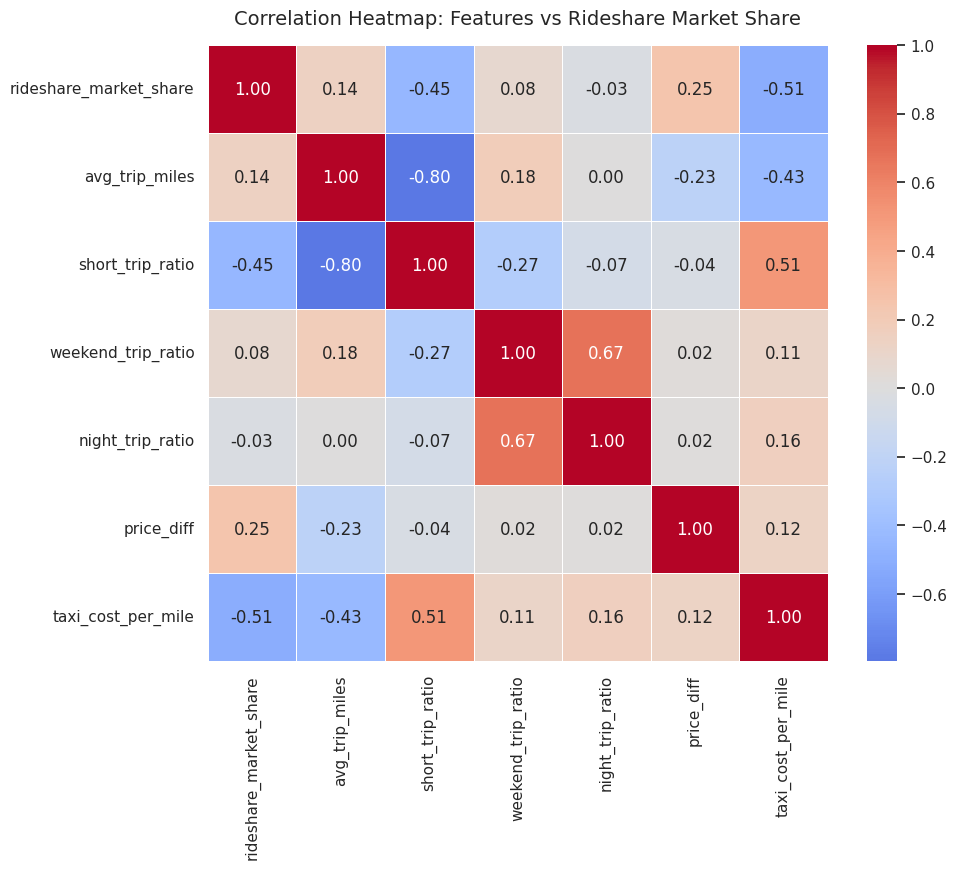

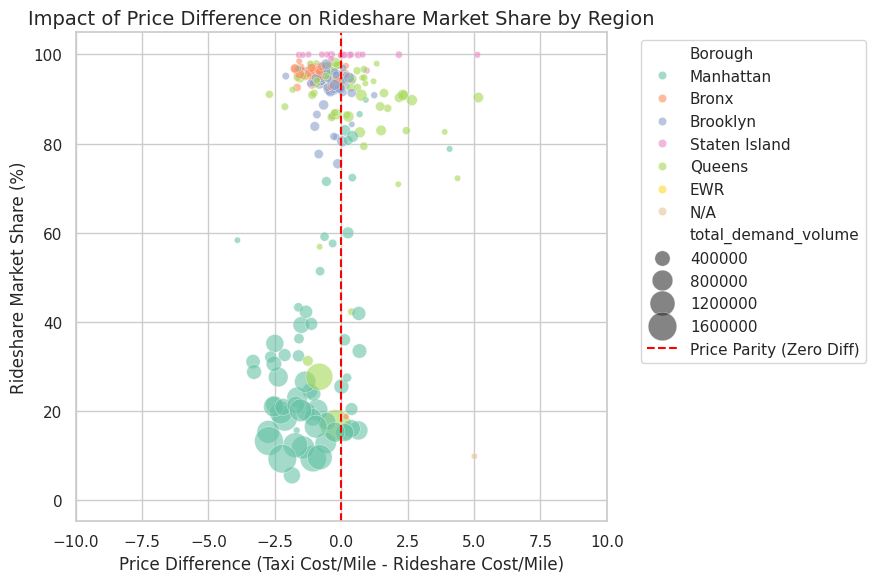

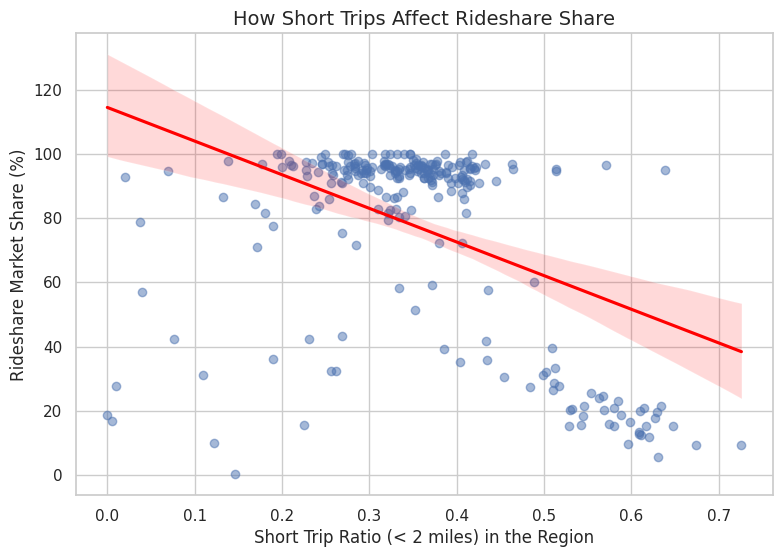

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 将聚合后的百行级别的数据拉取到 Pandas，方便画图
pdf = eda_df.toPandas()

# 设置绘图风格
sns.set_theme(style="whitegrid")

# ==========================================
# 绘图 1：特征相关性热力图 (寻找最强变量)
# ==========================================
plt.figure(figsize=(10, 8))
# 挑选你要看相关性的数值列
corr_cols = [
    'rideshare_market_share', 'avg_trip_miles', 'short_trip_ratio', 
    'weekend_trip_ratio', 'night_trip_ratio', 'price_diff', 'taxi_cost_per_mile'
]
# 计算 Pearson 相关系数
corr_matrix = pdf[corr_cols].corr()

# 画出热力图
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, center=0)
plt.title("Correlation Heatmap: Features vs Rideshare Market Share", fontsize=14, pad=15)
plt.show()
# 分析点：找找哪一行/列和 'rideshare_market_share' 颜色最深（绝对值最接近1）。

# ==========================================
# 绘图 2：散点图分析 - 价格差值 对 市场占比的影响
# ==========================================
plt.figure(figsize=(9, 6))
# x轴：价格差值 (出租车比网约车贵多少)
# y轴：网约车占比
# size：圆圈大小代表该地区的总打车需求量
scatter = sns.scatterplot(
    data=pdf, 
    x='price_diff', y='rideshare_market_share', 
    size='total_demand_volume', sizes=(20, 500), 
    alpha=0.6, hue='Borough', palette="Set2"  # 按行政区填色
)
plt.axvline(x=0, color='red', linestyle='--', label='Price Parity (Zero Diff)')

plt.title("Impact of Price Difference on Rideshare Market Share by Region", fontsize=14)
plt.xlabel("Price Difference (Taxi Cost/Mile - Rideshare Cost/Mile)", fontsize=12)
plt.ylabel("Rideshare Market Share (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# 将 X 轴的显示范围限制在 -10 到 +10 之间，聚焦核心博弈区
plt.xlim(-10, 10)
plt.tight_layout()
plt.show()
# 分析点：正常情况下，散点应该呈现向右上方的趋势（出租车越贵的地方，网约车占比越高）。

# ==========================================
# 绘图 3：回归拟合图 - 短途单比例 对 市场占比的影响
# ==========================================
plt.figure(figsize=(9, 6))
sns.regplot(
    data=pdf, 
    x='short_trip_ratio', y='rideshare_market_share',
    scatter_kws={'alpha':0.5, 'color':'#4C72B0'}, line_kws={'color':'red'}
)
plt.title("How Short Trips Affect Rideshare Share", fontsize=14)
plt.xlabel("Short Trip Ratio (< 2 miles) in the Region", fontsize=12)
plt.ylabel("Rideshare Market Share (%)", fontsize=12)
plt.show()
# 分析点：通常这条线会是向下的，因为在极其拥堵且都是短途出行的区域（如曼哈顿市中心），乘客更倾向于出门直接招手拦黄出租，而不是在路边干等网约车。